In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

# load data
df = pd.read_csv("/Users/abc/Desktop/papers/1. Papers/18.Multi-classifier-paper-cmc/current_study-without-lepto.csv")

df.head(5)


,Study_ID,S.No,age,gender,year,month,fever,fever_duration,abdominal_pain,abdpain_duration,...,malarial_pos,dengue,dengue_pos,scrub_typhus,spotted_fever,leptospirosis,blood_culture,multiple_virus_pcr,diagnosis,aufi_icmr_ai_form_complete
0,2014_12_4581,4581,60,2,2014,12,1,10,0,0,...,0,3,0,1,3,3,5,3,Scrub Typhus,1
1,2022_10_12297,12297,49,2,2022,10,1,17,1,2,...,0,3,0,1,3,3,5,3,Scrub Typhus,1
2,2012_9_3328,3328,45,2,2012,9,1,14,1,10,...,0,2,0,1,3,2,5,3,Scrub Typhus,1
3,2006_11_420,420,22,2,2006,11,1,30,0,0,...,0,2,0,1,3,2,5,3,Scrub Typhus,1
4,2011_1_2521,2521,60,2,2011,1,1,18,0,0,...,0,3,0,1,3,3,5,3,Scrub Typhus,1


In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

# load data
df1 = pd.read_csv("/Users/abc/Desktop/papers/1. Papers/18.Multi-classifier-paper-cmc/code for EDA/Table_combined.csv")

df1.head(5)

,Disease,Variable,Odds Ratio (OR),95% Confidence Interval (95% CI),p_value
0,Enteric Fever,fever_duration,1.1591,1.1415 - 1.1770,5.560000e-80
1,Enteric Fever,abdominal_pain,1.3498,1.1209 - 1.6254,1.555372e-03
2,Enteric Fever,abdpain_duration,0.9892,0.9787 - 0.9998,4.625209e-02
3,Enteric Fever,breathlessness,0.6936,0.4884 - 0.9849,4.085174e-02
4,Enteric Fever,breathlessness_duration,0.9591,0.9311 - 0.9878,5.523342e-03


In [3]:
x = df1["Variable"].unique()
x

array(['fever_duration', 'abdominal_pain', 'abdpain_duration',
       'breathlessness', 'breathlessness_duration', 'cough',
       'cough_duration', 'joint_pain', 'seizures', 'myalgia', 'vomiting',
       'rash', 'gcs', 'hb', 'nu', 'ly', 'mo', 'platelets', 'sodium', 'tb',
       'db', 'protein', 'albumin', 'alkp', 'inotropes', 'ventilation',
       'icu', 'hosp_staty', 'jaundice', 'altered_sensorium', 'headache',
       'tc', 'creatinine', 'sgot', 'fever', 'dysuria', 'rash_type',
       'eschar', 'sgpt'], dtype=object)

### features based Odds Ratio (OR)	95% Confidence Interval (95% CI)	p_value

In [4]:
features = ['fever_duration', 'abdominal_pain', 'abdpain_duration',
       'breathlessness', 'breathlessness_duration', 'cough',
       'cough_duration', 'joint_pain', 'seizures', 'myalgia', 'vomiting',
       'rash', 'gcs', 'hb', 'nu', 'ly', 'mo', 'platelets', 'sodium', 'tb',
       'db', 'protein', 'albumin', 'alkp', 'inotropes', 'ventilation',
       'icu', 'hosp_staty', 'jaundice', 'altered_sensorium', 'headache',
       'tc', 'creatinine', 'sgot', 'fever', 'dysuria', 'rash_type',
       'eschar', 'sgpt']

## features after karthik sir discuusion

In [4]:
features = ['fever_duration',
       'breathlessness', 'cough','joint_pain', 'seizures', 'myalgia', 'vomiting',
       'rash', 'gcs', 'hb', 'nu', 'ly', 'mo', 'platelets', 'sodium', 'tb',
       'db', 'alkp', 'jaundice', 
       'tc', 'creatinine', 'sgot',
       'eschar', 'sgpt']

In [5]:
df[features]

,fever_duration,breathlessness,cough,joint_pain,seizures,myalgia,vomiting,rash,gcs,hb,...,sodium,tb,db,alkp,jaundice,tc,creatinine,sgot,eschar,sgpt
0,10,0,0,0,0,0,0,0,11,9.9,...,186,0.70,0.10,234,0,7900,1.37,61.0,1,17.0
1,17,0,0,0,0,0,0,0,15,10.3,...,177,0.59,0.10,95,0,6100,1.00,90.0,0,107.0
2,14,1,0,0,0,0,0,0,8,10.3,...,168,0.70,0.10,55,0,6400,0.82,32.0,1,12.0
3,30,0,0,0,0,0,1,0,15,9.8,...,168,1.50,0.70,226,0,10300,5.00,64.0,0,57.0
4,18,0,1,0,0,0,0,0,7,10.9,...,167,0.70,0.20,85,0,6100,0.90,35.0,1,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14282,10,0,0,0,0,0,0,0,15,0.0,...,0,0.00,0.00,0,0,0,0.00,0.0,1,0.0
14283,2,1,0,0,0,0,0,1,15,0.0,...,0,0.00,0.00,0,0,0,0.00,0.0,0,0.0
14284,4,0,0,0,0,1,1,0,15,0.0,...,0,0.00,0.00,0,0,0,0.00,0.0,0,0.0
14285,8,0,0,0,0,0,1,0,15,0.0,...,0,0.00,0.00,0,0,0,0.00,0.0,0,0.0


In [6]:
X = df[features]
y = df["diagnosis"]

## Encode target labels.

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class mapping")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Class mapping
0 -> Dengue
1 -> Enteric Fever
2 -> Malaria
3 -> Scrub Typhus


## XGB Model

Class distribution in training set
Counter({3: 4931, 0: 4497, 1: 1160, 2: 841})
Test Accuracy: 0.8110566829951015

Classification Report

               precision    recall  f1-score   support

       Dengue       0.82      0.89      0.85      1125
Enteric Fever       0.61      0.42      0.50       290
      Malaria       0.83      0.58      0.68       210
 Scrub Typhus       0.83      0.87      0.85      1233

     accuracy                           0.81      2858
    macro avg       0.77      0.69      0.72      2858
 weighted avg       0.80      0.81      0.80      2858



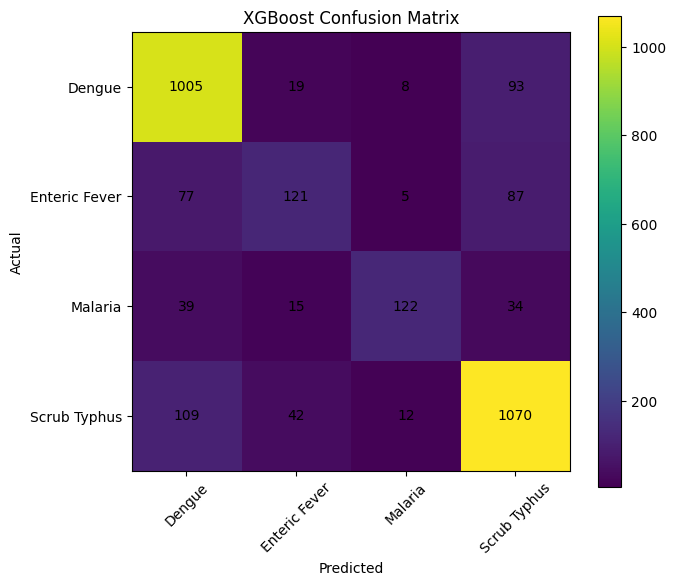

In [8]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Class distribution in training set")
print(Counter(y_train))

# XGBoost model without class weights
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42
)

# fit model
xgb_model.fit(X_train, y_train)

# predictions
y_test_pred = xgb_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report\n")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)

# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.colorbar()
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()


In [9]:
import pickle 

# save model to pkl file
with open("xgboost_multiclass_model2.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("Model saved as xgboost_multiclass_model2.pkl")


Model saved as xgboost_multiclass_model2.pkl


In [10]:
with open("label_encoder2.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Label encoder saved as label_encoder2.pkl")


Label encoder saved as label_encoder2.pkl


/Users/abc/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (2858, 24, 4)


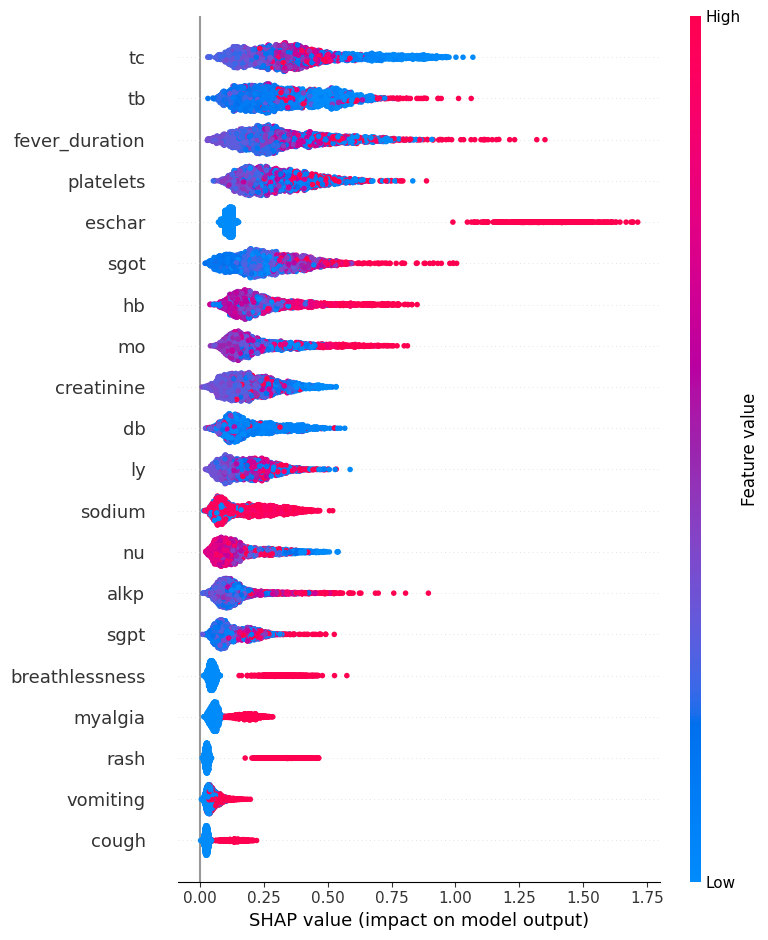

SHAP summary for class: Dengue


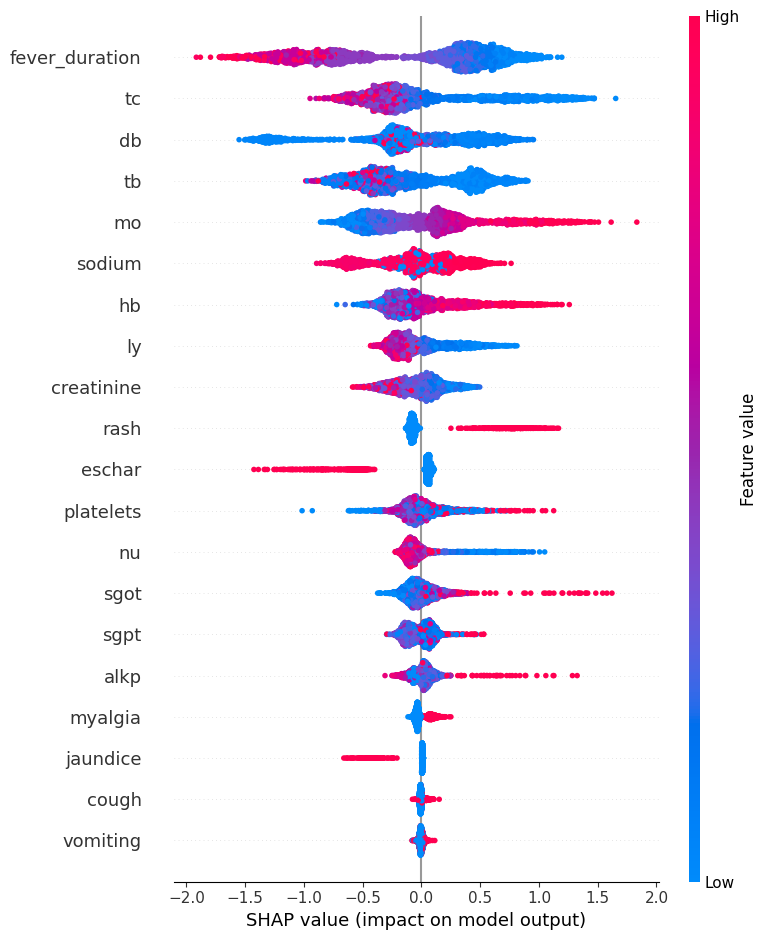

SHAP summary for class: Enteric Fever


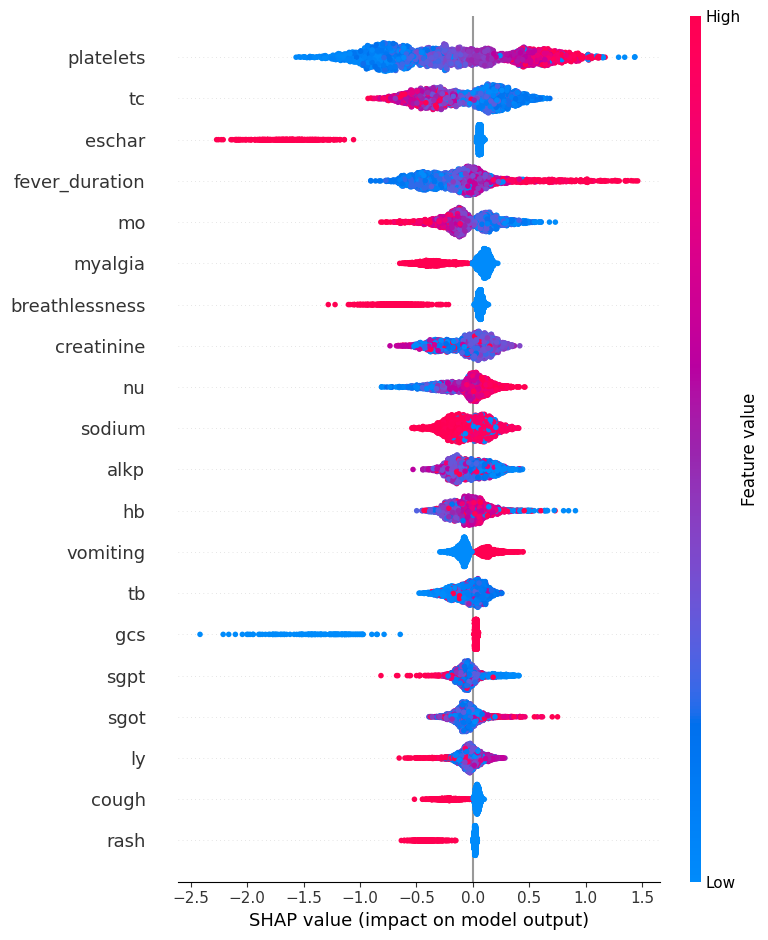

SHAP summary for class: Malaria


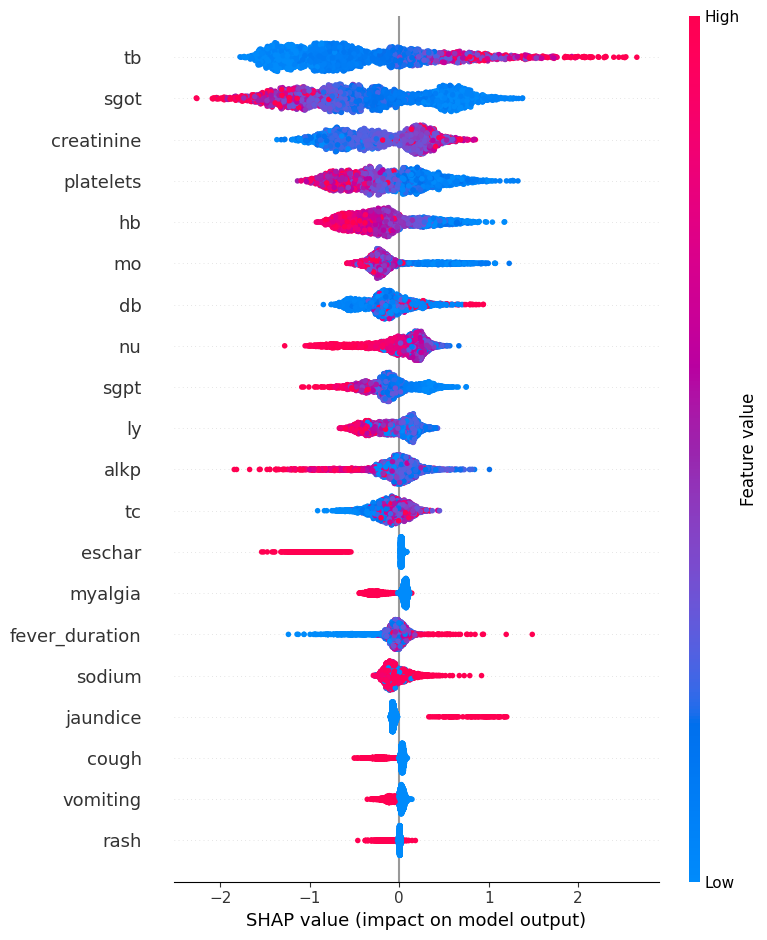

SHAP summary for class: Scrub Typhus


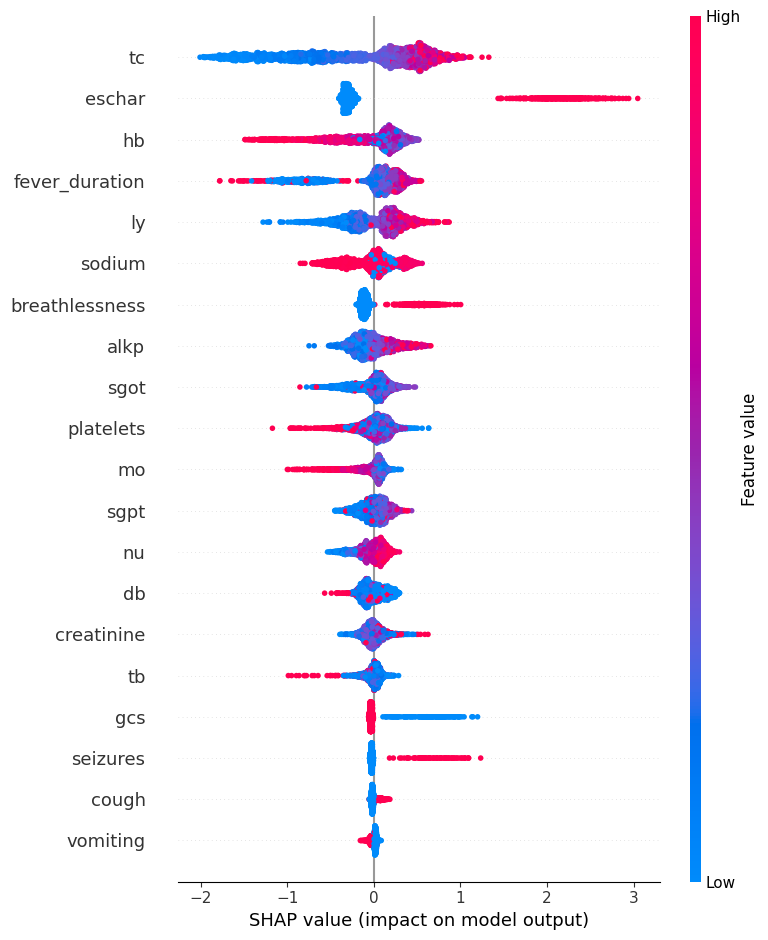

In [11]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# create explainer
explainer = shap.TreeExplainer(xgb_model)

# compute SHAP values
# shape: (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

# -----------------------------------
# 1. Global SHAP summary plot
# -----------------------------------
# mean absolute SHAP over classes
shap_values_global = np.mean(np.abs(shap_values), axis=2)

shap.summary_plot(
    shap_values_global,
    X_test,
    feature_names=X.columns,
    show=True
)

# -----------------------------------
# 2. Class-wise SHAP summary plots
# -----------------------------------
for class_idx, class_name in enumerate(label_encoder.classes_):
    print("SHAP summary for class:", class_name)
    shap.summary_plot(
        shap_values[:, :, class_idx],
        X_test,
        feature_names=X.columns,
        show=True
    )

## Decision Tree

Decision Tree Test Accuracy: 0.6546536039188243

Decision Tree Classification Report

               precision    recall  f1-score   support

       Dengue       0.82      0.69      0.75      1125
Enteric Fever       0.27      0.59      0.38       290
      Malaria       0.37      0.62      0.46       210
 Scrub Typhus       0.85      0.64      0.73      1233

     accuracy                           0.65      2858
    macro avg       0.58      0.64      0.58      2858
 weighted avg       0.75      0.65      0.68      2858



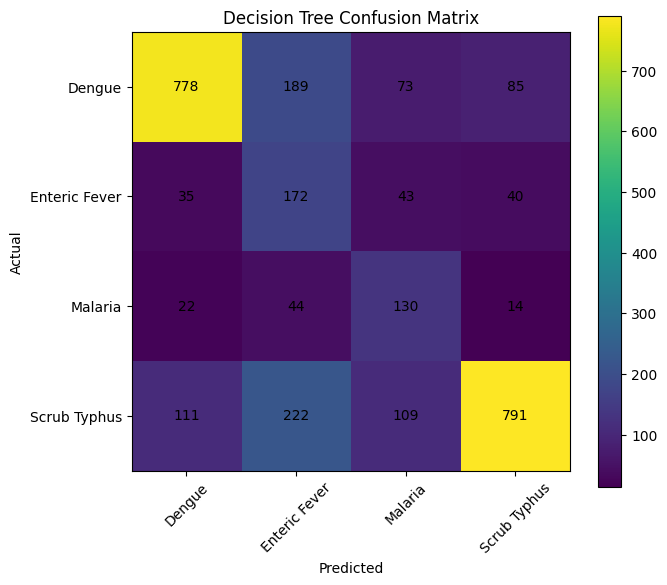

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

dt_model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

y_test_pred_dt = dt_model.predict(X_test)

print("Decision Tree Test Accuracy:", accuracy_score(y_test, y_test_pred_dt))
print("\nDecision Tree Classification Report\n")
print(classification_report(
    y_test,
    y_test_pred_dt,
    target_names=label_encoder.classes_
))

cm_dt = confusion_matrix(y_test, y_test_pred_dt)

plt.figure(figsize=(7, 6))
plt.imshow(cm_dt)
plt.colorbar()
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

for i in range(cm_dt.shape[0]):
    for j in range(cm_dt.shape[1]):
        plt.text(j, i, cm_dt[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()


## Random Forest

Random Forest Test Accuracy: 0.7589223233030091

Random Forest Classification Report

               precision    recall  f1-score   support

       Dengue       0.80      0.83      0.81      1125
Enteric Fever       0.41      0.60      0.49       290
      Malaria       0.67      0.63      0.65       210
 Scrub Typhus       0.87      0.75      0.81      1233

     accuracy                           0.76      2858
    macro avg       0.69      0.70      0.69      2858
 weighted avg       0.78      0.76      0.77      2858



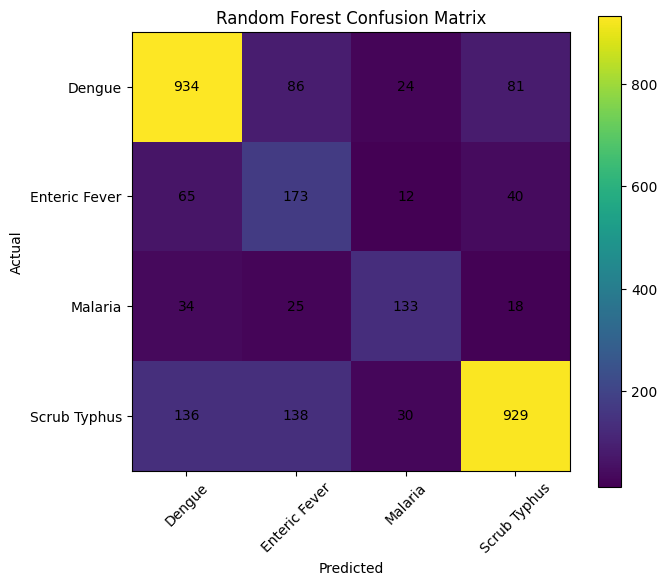

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_test_pred_rf = rf_model.predict(X_test)

print("Random Forest Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("\nRandom Forest Classification Report\n")
print(classification_report(
    y_test,
    y_test_pred_rf,
    target_names=label_encoder.classes_
))

cm_rf = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(7, 6))
plt.imshow(cm_rf)
plt.colorbar()
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


## Esemble

Ensemble Test Accuracy: 0.7827151854443667

Ensemble Classification Report

               precision    recall  f1-score   support

       Dengue       0.83      0.86      0.84      1125
Enteric Fever       0.46      0.54      0.50       290
      Malaria       0.66      0.64      0.65       210
 Scrub Typhus       0.86      0.79      0.82      1233

     accuracy                           0.78      2858
    macro avg       0.70      0.71      0.70      2858
 weighted avg       0.79      0.78      0.79      2858



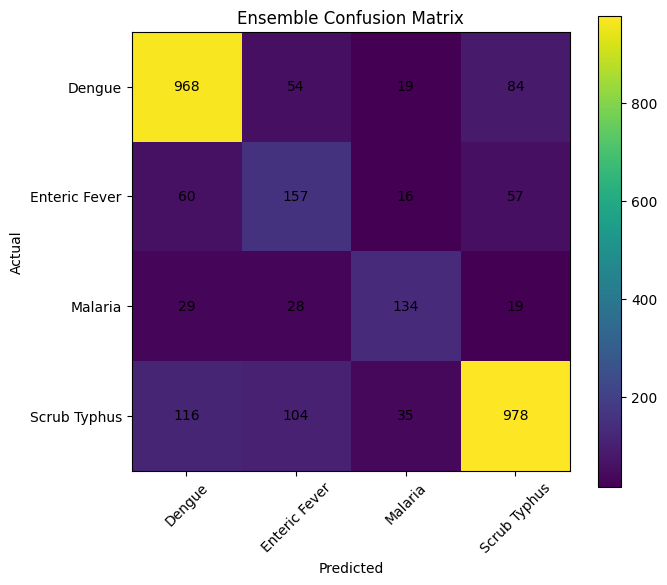

In [14]:
from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(
    estimators=[
        ("dt", dt_model),
        ("rf", rf_model),
        ("xgb", xgb_model)
    ],
    voting="soft",
    n_jobs=-1
)

ensemble_model.fit(X_train, y_train)

y_test_pred_ens = ensemble_model.predict(X_test)

print("Ensemble Test Accuracy:", accuracy_score(y_test, y_test_pred_ens))
print("\nEnsemble Classification Report\n")
print(classification_report(
    y_test,
    y_test_pred_ens,
    target_names=label_encoder.classes_
))

cm_ens = confusion_matrix(y_test, y_test_pred_ens)

plt.figure(figsize=(7, 6))
plt.imshow(cm_ens)
plt.colorbar()
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

for i in range(cm_ens.shape[0]):
    for j in range(cm_ens.shape[1]):
        plt.text(j, i, cm_ens[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Ensemble Confusion Matrix")
plt.tight_layout()
plt.show()
